# Scenario 1B — Discrete Mountain Car with Augmented Y-State

**Objective:** Compare whether adding the car's vertical position helps DQN on the standard minimum-steps Mountain Car task.

**Baseline env:** `MountainCar-v0` with observation `(position, velocity)`  
**Augmented env:** `MountainCar-v1` with observation `(position, velocity, height)`  
**Reward:** `-1` per timestep, unchanged from `MountainCar-v0`


## What changes in `MountainCar-v1`?

The extra state is the car height on the hill:

`height = sin(3 * position) * 0.45 + 0.55`

This is the same geometry used by the classic control environment renderer. The reward and transition dynamics stay the same; only the observation is augmented.

**Important expectation:** because `height` is a deterministic function of `position`, it usually adds **redundant information**, not fundamentally new information. So this experiment is useful, but `v1` is not expected to dramatically outperform `v0`.


In [1]:
import os
import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from mountaincar_v1 import register_mountaincar_v1

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('runs', exist_ok=True)

register_mountaincar_v1()
print('Setup complete.')


Setup complete.


In [2]:
env_v0 = gym.make('MountainCar-v0')
env_v1 = gym.make('MountainCar-v1')

obs_v0, _ = env_v0.reset(seed=SEED)
obs_v1, _ = env_v1.reset(seed=SEED)

print('MountainCar-v0 observation space:', env_v0.observation_space)
print('Sample v0 observation:', obs_v0)
print()
print('MountainCar-v1 observation space:', env_v1.observation_space)
print('Sample v1 observation:', obs_v1)
print('State meaning in v1: [position, velocity, height]')


MountainCar-v0 observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Sample v0 observation: [-0.4452088  0.       ]

MountainCar-v1 observation space: Box([-1.2  -0.07  0.  ], [0.6  0.07 1.  ], (3,), float32)
Sample v1 observation: [-0.4452088   0.          0.11238636]
State meaning in v1: [position, velocity, height]


/Users/onosaeka/Uni/BCSAI/3-2/RL/reinforcement-learning/.venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment MountainCar-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


## DQN Setup

This notebook uses a slightly stronger DQN baseline than the original scenario notebook:

- epsilon decays **per episode**, not per gradient step
- replay starts only after a warmup period
- **Double DQN** target to reduce overestimation noise
- larger hidden width and batch size for smoother training

That makes the comparison between `v0` and `v1` more meaningful.


In [3]:
class DQNNet(nn.Module):
    def __init__(self, state_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buf = deque(maxlen=capacity)

    def push(self, *transition):
        self.buf.append(transition)

    def sample(self, batch_size):
        return random.sample(self.buf, batch_size)

    def __len__(self):
        return len(self.buf)


class DQNAgent:
    def __init__(
        self,
        state_dim,
        n_actions,
        lr=5e-4,
        gamma=0.99,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay=0.9985,
        batch_size=128,
        target_update=250,
        learn_starts=1000,
        hidden=128,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.eps = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.target_update = target_update
        self.learn_starts = learn_starts
        self.grad_steps = 0

        self.policy_net = DQNNet(state_dim, n_actions, hidden=hidden)
        self.target_net = DQNNet(state_dim, n_actions, hidden=hidden)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.opt = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()
        self.buffer = ReplayBuffer()

    def act(self, state, greedy=False):
        if not greedy and np.random.random() < self.eps:
            return np.random.randint(self.n_actions)
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
            return int(self.policy_net(s).argmax(dim=1).item())

    def learn(self):
        if len(self.buffer) < max(self.batch_size, self.learn_starts):
            return

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        s = torch.as_tensor(np.array(states), dtype=torch.float32)
        a = torch.as_tensor(actions, dtype=torch.long).unsqueeze(1)
        r = torch.as_tensor(rewards, dtype=torch.float32).unsqueeze(1)
        ns = torch.as_tensor(np.array(next_states), dtype=torch.float32)
        d = torch.as_tensor(dones, dtype=torch.float32).unsqueeze(1)

        q_curr = self.policy_net(s).gather(1, a)
        with torch.no_grad():
            next_actions = self.policy_net(ns).argmax(dim=1, keepdim=True)
            q_next = self.target_net(ns).gather(1, next_actions)
            q_tgt = r + self.gamma * q_next * (1.0 - d)

        loss = self.loss_fn(q_curr, q_tgt)
        self.opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.opt.step()

        self.grad_steps += 1
        if self.grad_steps % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


def train_dqn(env, agent, n_episodes=2000, seed=SEED, label='DQN'):
    rewards_hist = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0.0
        done = False

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.buffer.push(state, action, reward, next_state, float(done))
            agent.learn()
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        rewards_hist.append(total_reward)

        if (ep + 1) % 200 == 0:
            avg = np.mean(rewards_hist[-100:])
            print(f'{label:>12}  ep {ep+1:4d}  avg(100)={avg:6.1f}  eps={agent.eps:.4f}')

    return np.array(rewards_hist)


In [4]:
N_EPISODES = 2000
COMMON_DQN_KWARGS = dict(
    lr=5e-4,
    gamma=0.99,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.9985,
    batch_size=128,
    target_update=250,
    learn_starts=1000,
    hidden=128,
)

print('Training baseline DQN on MountainCar-v0...')
dqn_v0 = DQNAgent(state_dim=2, n_actions=env_v0.action_space.n, **COMMON_DQN_KWARGS)
rewards_v0 = train_dqn(env_v0, dqn_v0, n_episodes=N_EPISODES, label='v0-DQN')

torch.save(dqn_v0.policy_net.state_dict(), 'checkpoints/s01b_dqn_v0.pth')
print('Saved -> checkpoints/s01b_dqn_v0.pth')

print('\nTraining augmented-state DQN on MountainCar-v1...')
dqn_v1 = DQNAgent(state_dim=3, n_actions=env_v1.action_space.n, **COMMON_DQN_KWARGS)
rewards_v1 = train_dqn(env_v1, dqn_v1, n_episodes=N_EPISODES, label='v1-DQN')

torch.save(dqn_v1.policy_net.state_dict(), 'checkpoints/s01b_dqn_v1.pth')
print('Saved -> checkpoints/s01b_dqn_v1.pth')


Training baseline DQN on MountainCar-v0...
      v0-DQN  ep  200  avg(100)=-200.0  eps=0.7407
      v0-DQN  ep  400  avg(100)=-200.0  eps=0.5486
      v0-DQN  ep  600  avg(100)=-198.7  eps=0.4063
      v0-DQN  ep  800  avg(100)=-188.1  eps=0.3009
      v0-DQN  ep 1000  avg(100)=-160.0  eps=0.2229
      v0-DQN  ep 1200  avg(100)=-137.2  eps=0.1651
      v0-DQN  ep 1400  avg(100)=-130.8  eps=0.1223
      v0-DQN  ep 1600  avg(100)=-125.5  eps=0.0906
      v0-DQN  ep 1800  avg(100)=-133.3  eps=0.0671
      v0-DQN  ep 2000  avg(100)=-120.8  eps=0.0500
Saved -> checkpoints/s01b_dqn_v0.pth

Training augmented-state DQN on MountainCar-v1...
      v1-DQN  ep  200  avg(100)=-200.0  eps=0.7407
      v1-DQN  ep  400  avg(100)=-200.0  eps=0.5486
      v1-DQN  ep  600  avg(100)=-191.8  eps=0.4063
      v1-DQN  ep  800  avg(100)=-175.9  eps=0.3009
      v1-DQN  ep 1000  avg(100)=-196.9  eps=0.2229
      v1-DQN  ep 1200  avg(100)=-193.3  eps=0.1651
      v1-DQN  ep 1400  avg(100)=-181.8  eps=0.1223
  

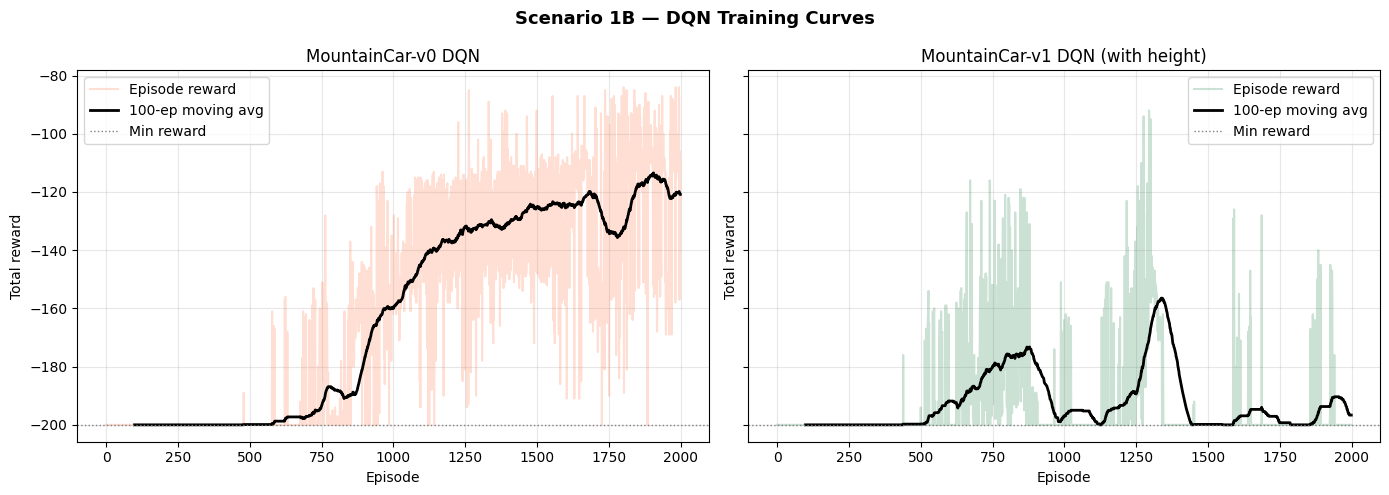

In [5]:
window = 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, rewards, title, color in [
    (axes[0], rewards_v0, 'MountainCar-v0 DQN', 'coral'),
    (axes[1], rewards_v1, 'MountainCar-v1 DQN (with height)', 'seagreen'),
]:
    ax.plot(rewards, alpha=0.25, color=color, label='Episode reward')
    if len(rewards) >= window:
        ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
        ax.plot(np.arange(window - 1, len(rewards)), ma, color='black', lw=2, label='100-ep moving avg')
    ax.axhline(-200, color='gray', ls=':', lw=1, label='Min reward')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total reward')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Scenario 1B — DQN Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('checkpoints/s01b_training_curves.png', dpi=150)
plt.show()


In [6]:
def evaluate(env, get_action_fn, n_episodes=100, seed=1000, label='Agent'):
    rewards, steps_list, successes = [], [], 0
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward, steps, done, success = 0.0, 0, False, False
        while not done:
            action = get_action_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1
            if terminated:
                success = True
        rewards.append(total_reward)
        if success:
            successes += 1
            steps_list.append(steps)

    print(f'\n{label}:')
    print(f'  Mean reward   : {np.mean(rewards):.2f} +/- {np.std(rewards):.2f}')
    print(f'  Success rate  : {successes}/{n_episodes} ({successes / n_episodes * 100:.1f}%)')
    if steps_list:
        print(f'  Mean steps    : {np.mean(steps_list):.1f} +/- {np.std(steps_list):.1f}')
    else:
        print('  Mean steps    : n/a (no successful episodes)')

    return {
        'rewards': rewards,
        'success_rate': successes / n_episodes,
        'steps': steps_list,
    }


v0_fn = lambda s: dqn_v0.act(s, greedy=True)
v1_fn = lambda s: dqn_v1.act(s, greedy=True)

v0_eval = evaluate(env_v0, v0_fn, label='MountainCar-v0 DQN')
v1_eval = evaluate(env_v1, v1_fn, label='MountainCar-v1 DQN')

print('\n' + '=' * 74)
print(f'{"Metric":<28} {"v0 DQN":>18} {"v1 DQN":>18}')
print('-' * 74)
print(f'{"Mean reward":<28} {np.mean(v0_eval["rewards"]):>18.2f} {np.mean(v1_eval["rewards"]):>18.2f}')
print(f'{"Std reward":<28} {np.std(v0_eval["rewards"]):>18.2f} {np.std(v1_eval["rewards"]):>18.2f}')
print(f'{"Success rate (%)":<28} {v0_eval["success_rate"]*100:>18.1f} {v1_eval["success_rate"]*100:>18.1f}')
print(f'{"Mean steps to goal":<28} {(np.mean(v0_eval["steps"]) if v0_eval["steps"] else float("nan")):>18.1f} {(np.mean(v1_eval["steps"]) if v1_eval["steps"] else float("nan")):>18.1f}')



MountainCar-v0 DQN:
  Mean reward   : -99.06 +/- 9.76
  Success rate  : 100/100 (100.0%)
  Mean steps    : 99.1 +/- 9.8

MountainCar-v1 DQN:
  Mean reward   : -200.00 +/- 0.00
  Success rate  : 0/100 (0.0%)
  Mean steps    : n/a (no successful episodes)

Metric                                   v0 DQN             v1 DQN
--------------------------------------------------------------------------
Mean reward                              -99.06            -200.00
Std reward                                 9.76               0.00
Success rate (%)                          100.0                0.0
Mean steps to goal                         99.1                nan


## Reading the result

If `MountainCar-v1` is only similar to `MountainCar-v0`, that is expected. The extra `height` feature is fully determined by `position`, so it does not add new physical information about the system. At best it may help the network represent the hill shape a bit more directly; at worst it is just redundant.

If you want a genuinely richer state experiment, a better next step would be adding a feature that is **not** a simple deterministic re-encoding of position.
